IMPORT

In [54]:
from PIL import Image, ImageEnhance, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from transformers import pipeline
import scipy.io

FOGGY AUXILIARY FUNCTIONS

In [2]:
def enhances(img, saturation, brightness, contrast, alpha):

    saturation_factor = 1 + (saturation - 1) * alpha
    brightness_factor = 1 + (brightness - 1) * alpha
    contrast_factor = 1 + (contrast - 1) * alpha

    # Apply saturation enhancement
    enhancer = ImageEnhance.Color(img)
    img_2 = enhancer.enhance(saturation_factor)

    # Apply brightness enhancement
    enhancer2 = ImageEnhance.Brightness(img_2)
    img_2 = enhancer2.enhance(brightness_factor)

    # Apply contrast enhancement
    enhancer3 = ImageEnhance.Contrast(img_2)
    img_2 = enhancer3.enhance(contrast_factor)

    return img_2

In [6]:
def get_fog(depth_image,color, vis=0.5):

    enhancer = ImageEnhance.Brightness(depth_image)
    depth_image = enhancer.enhance(30*(vis**3))     # Rescale the depth
    depth_array = np.array(depth_image)

    fog_layer = Image.new('RGBA', depth_image.size, color)
    fog_array = np.array(fog_layer)
    
    noise = np.random.normal(0,3, (depth_image.size[1],depth_image.size[0]))
    noise = noise.astype(np.uint8)
    fog_array[:, :, 0] += noise  # Red channel
    fog_array[:, :, 1] += noise  # Green channel
    fog_array[:, :, 2] += noise  # Blue channel
    fog_array[:, :, 0] = np.clip(fog_array[:, :, 0], 0, 255)
    fog_array[:, :, 1] = np.clip(fog_array[:, :, 1], 0, 255)
    fog_array[:, :, 2] = np.clip(fog_array[:, :, 2], 0, 255)
    fog_array[:, :, 3] = (255 - depth_array) # Set the alpha channel of the fog layer

    fog_layer_alpha = Image.fromarray(fog_array, 'RGBA')

    return fog_layer_alpha

In [3]:
def get_highlight(rgb_image,p=100):

    result = Image.new('RGBA', rgb_image.size, (0,0,0,0))

    result_array = np.array(result)
    image_array = np.array(rgb_image)

    brightness = 0.2126*image_array[:,:,0]+0.7152*image_array[:,:,1]+0.0722*image_array[:,:,2]

    mean_brightness = np.mean(brightness)

    result_array[:,:,0:3] = image_array
    result_array[:,:,3] = brightness*((brightness - mean_brightness)>p)

    result = Image.fromarray(result_array, 'RGBA')

    r, g, b, a = result.split()
    r = r.filter(ImageFilter.BLUR)
    g = g.filter(ImageFilter.BLUR)
    b = b.filter(ImageFilter.BLUR)
    result = Image.merge("RGBA", (r, g, b, a))

    return result

In [4]:
def get_color(image):

    img = np.array(image)
    mean = np.mean(img, axis = (0, 1))
    coeff = 0.2126*mean[0]+0.7152*mean[1]+0.0722*mean[2]
    n = -(1/255)*coeff*0.8 + 0.8
    color = n*np.append(mean, 0) + (1-n)*np.array([216, 216, 216, 0])
    color = color.astype(np.uint8)
    color = tuple(map(int,color))

    return color

In [5]:
def foggy(img,vis,pipe, night = False):

    color = get_color(img)

    depth = pipe(img)["depth"]

    img_enc = enhances(img,0.4,0.8,1.1, 1-vis)

    fog = get_fog(depth,color,vis)
    img_fog = Image.alpha_composite(img_enc.convert('RGBA'),fog)

    if night:
        highlight = get_highlight(img,70*vis +100)
        img_fog = Image.alpha_composite(img_fog.convert('RGBA'),highlight)

    img_fog = img_fog.convert('RGB')
    
    return img_fog

In [112]:
def display_images(images = [], image_names = [], rows = 1, cols = None):

    if cols is None:
        cols = len(images)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, 10))

    axes = axes.flatten()

    for i in range(len(images)):
        axes[i].imshow(images[i])
        axes[i].axis('off')
        
        if image_names:
            axes[i].text(0.5, 1.05, image_names[i], ha='center', va='bottom', 
                         transform=axes[i].transAxes, fontsize=10, color='black', fontweight='bold')

    for j in range(len(images), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

In [8]:
pipe = pipeline(task="depth-estimation",model="depth-anything/Depth-Anything-V2-Base-hf", device = 0)

Device set to use cpu


OPTICAL VISIBILITY ESTIMATION FROM IMAGE

In [94]:
img = Image.open("resources/visibility/visibility2.jpg").convert("RGB")
mat_file = 'resources/visibility/depth2.mat'
data = scipy.io.loadmat(mat_file)
depth_data = data['Position3DGrid']
depth = depth_data[:, :, 3]
depth_img = Image.fromarray(np.uint8(depth))
depth_img = depth_img.resize((229,305))

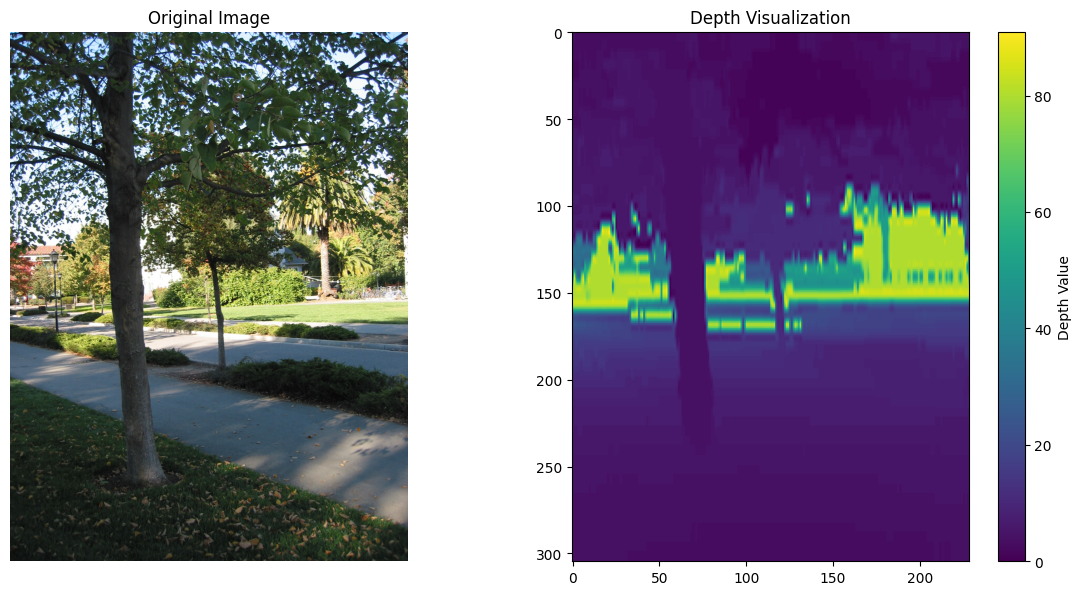

In [99]:

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(img)
axs[0].set_title('Original Image')
axs[0].set_xlabel('X-axis')
axs[0].set_ylabel('Y-axis')
axs[0].axis('off') 

im = axs[1].imshow(depth_img, cmap='viridis')
axs[1].set_title('Depth Visualization')
axs[1].axis('on') 

cbar = fig.colorbar(im, ax=axs[1], orientation='vertical', label='Depth Value')

plt.tight_layout()
plt.show()

In [101]:
# find two notable point
array = np.array(depth_img)
print(array[150,50:85])
print(array[125,165:200])
#first tree at 4 meters
#far tree at 49 meters

[84 50 86 85 90 49  0  2  2  3  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  2 19 74 85 84 84 84 84 84 82]
[84 84 82 80 80 80 80 80 80 80 80 80 81 71 50 49 54 74 81 80 80 80 80 80
 80 80 80 80 80 80 80 80 80 80 80]


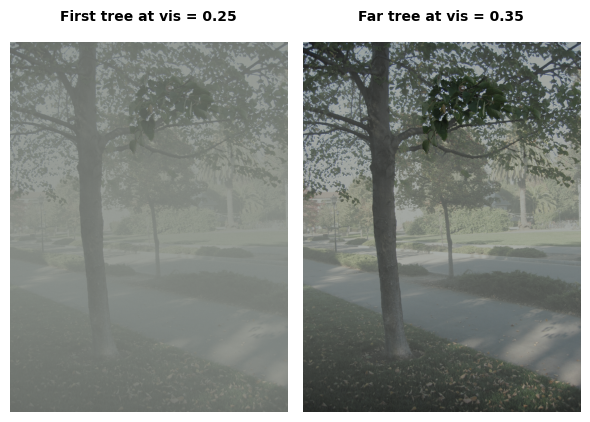

In [102]:
# find two visibility parameter for two notable point
visibility_near = 0.25
visibility_far = 0.35

first_tree = foggy(img, visibility_near, pipe)
far_tree = foggy(img, visibility_far, pipe)

display_images(
    [first_tree, far_tree],
    [f"First tree at vis = {visibility_near}", f"Far tree at vis = {visibility_far}"]
)

Fitted parameters: a = 0.0076155350181835585, b = 25.055386843257047


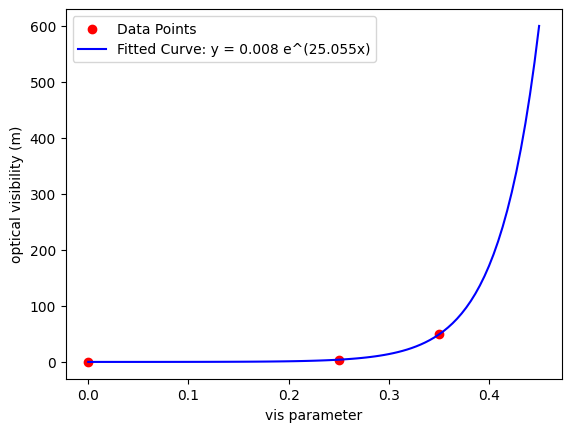

In [104]:
x = np.array([0, visibility_near, visibility_far])
y = np.array([0, 4, 49])

def exponential_model(x, a, b):
    return a * np.exp(b * x)

popt, _= curve_fit(exponential_model, x, y, p0=[1, 1]) 
a, b = popt

print(f"Fitted parameters: a = {a}, b = {b}")

x_fit = np.linspace(0, max(x)+0.1, 100)
y_fit = exponential_model(x_fit, a, b)

plt.scatter(x, y, color='red', label='Data Points')
plt.plot(x_fit, y_fit, label=f'Fitted Curve: y = {a:.3f} e^({b:.3f}x)', color='blue')
plt.xlabel('vis parameter')
plt.ylabel('optical visibility (m)')
plt.legend()
plt.show()

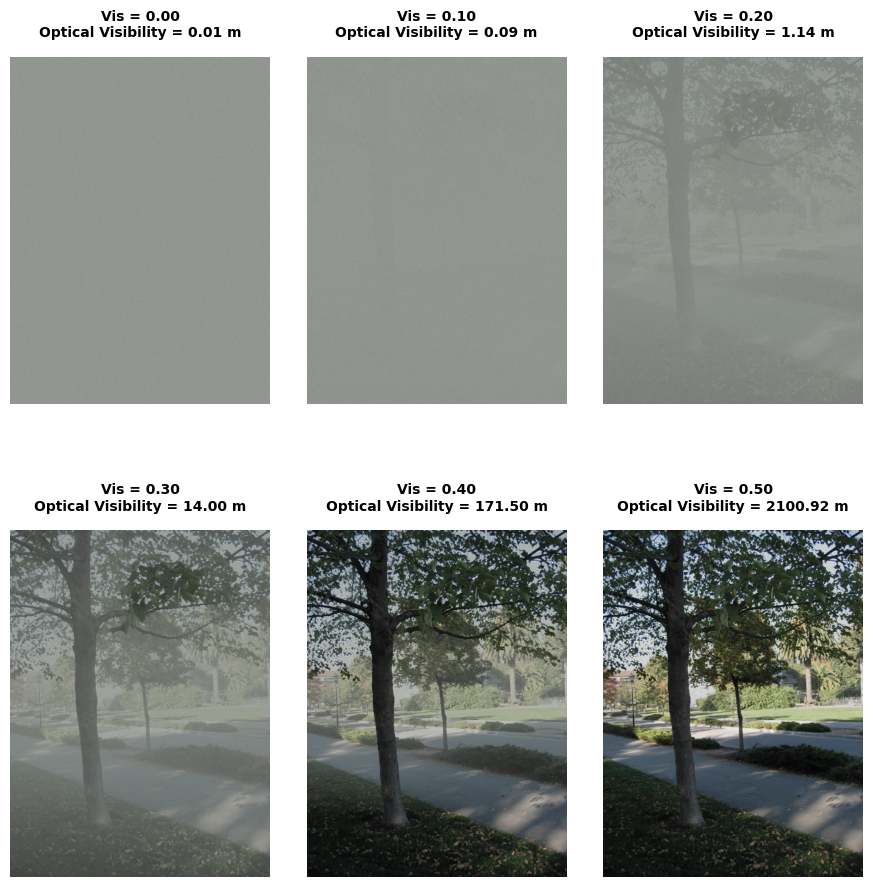

In [115]:
#Example
img = img.resize((426,568))
fogs = []
titles = []

vis = 0.0

for i in range(6):
    fogs.append(foggy(img,vis,pipe))
    optical_vis = exponential_model(vis, a, b)  # Compute the fitted curve value
    titles.append(f"Vis = {vis:.2f}\nOptical Visibility = {optical_vis:.2f} m")
    vis +=0.1

display_images(fogs, titles, rows=2, cols=3)